In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

In [2]:
pio.renderers.default = "notebook_connected"

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv("social_media_engagement_5000.csv")
print("Shape:", df.shape)
df.head()

Shape: (5000, 19)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [5]:
df.dtypes

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

In [6]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y', errors='coerce')

# Ensure categorical/boolean columns have sensible dtypes
df['gender'] = df['gender'].astype('category')
df['post_type'] = df['post_type'].astype('category')
df['post_category'] = df['post_category'].astype('category')
df['country'] = df['country'].astype('category')
df['device_type'] = df['device_type'].astype('category')
df['sentiment'] = df['sentiment'].astype('category')
df['is_verified'] = df['is_verified'].astype(bool)

print(df[['posted_at']].dtypes)
df.dtypes

posted_at    datetime64[ns]
dtype: object


user_id                      int64
age                        float64
gender                    category
country                   category
post_id                      int64
post_type                 category
post_category             category
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type               category
sentiment                 category
hashtags                    object
engagement_rate            float64
dtype: object

In [7]:
likes_arr = df['likes'].to_numpy()

print("NumPy array dtype:", likes_arr.dtype)
print("Total likes (nansum):", np.nansum(likes_arr))
print("Mean likes (nanmean):", round(np.nanmean(likes_arr), 2))
print("Max likes (nanmax):", np.nanmax(likes_arr))
print("Min likes (nanmin):", np.nanmin(likes_arr))
print("Standard deviation (nanstd):", round(np.nanstd(likes_arr), 2))

NumPy array dtype: float64
Total likes (nansum): 49019162.0
Mean likes (nanmean): 10107.04
Max likes (nanmax): 19998.0
Min likes (nanmin): 10.0
Standard deviation (nanstd): 5789.22


In [8]:
comments_arr = df['comments'].to_numpy()
shares_arr = df['shares'].to_numpy()
total_engagement_arr = np.nansum(np.vstack([likes_arr, comments_arr, shares_arr]), axis=0)
print("\nFirst 10 total engagement values (NumPy vectorized sum):")
print(total_engagement_arr[:10])


First 10 total engagement values (NumPy vectorized sum):
[ 8522. 16163.  6161.  7482. 16717. 14424. 15444. 10181.  4276. 17639.]


In [9]:
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
age,150,3.0
gender,150,3.0
likes,150,3.0
comments,150,3.0
shares,150,3.0
sentiment,150,3.0


In [10]:
for col in ['likes', 'comments', 'shares', 'age']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median = {median_val}")

for col in ['gender', 'sentiment']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled {col} missing values with mode = '{mode_val}'")

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Filled likes missing values with median = 10105.5
Filled comments missing values with median = 1497.0
Filled shares missing values with median = 1012.0
Filled age missing values with median = 38.0
Filled gender missing values with mode = 'Male'
Filled sentiment missing values with mode = 'positive'

Remaining missing values:
0


In [11]:
full_dupes = df.duplicated().sum()
post_id_dupes = df.duplicated(subset=['post_id']).sum()
print("Full-row duplicates:", full_dupes)
print("Duplicate post_id entries:", post_id_dupes)

Full-row duplicates: 0
Duplicate post_id entries: 9


In [12]:
df = df.drop_duplicates(subset=['post_id'], keep='first').reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4991, 19)


In [13]:
for col in ['gender', 'post_type', 'post_category', 'country', 'device_type', 'sentiment']:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [14]:
df['gender'] = df['gender'].str.title()
df['sentiment'] = df['sentiment'].str.lower()

print("Gender categories:", df['gender'].unique())
print("Sentiment categories:", df['sentiment'].unique())
print("Post type categories:", df['post_type'].unique())
print("Device type categories:", df['device_type'].unique())

Gender categories: ['Female' 'Male' 'Other']
Sentiment categories: ['negative' 'positive' 'neutral']
Post type categories: ['image' 'reel' 'text' 'video']
Device type categories: ['mobile' 'tablet' 'desktop']


In [15]:
unrealistic_mask = (
    (df['likes'] > df['impression_count']) |
    (df['comments'] > df['impression_count']) |
    (df['shares'] > df['impression_count'])
)
print("Rows with unrealistic engagement metrics (before fix):", unrealistic_mask.sum())

Rows with unrealistic engagement metrics (before fix): 466


In [16]:
df['likes'] = np.minimum(df['likes'], df['impression_count'])
df['comments'] = np.minimum(df['comments'], df['impression_count'])
df['shares'] = np.minimum(df['shares'], df['impression_count'])

In [17]:
df['engagement_rate'] = (df['likes'] + df['comments'] + df['shares']) / df['impression_count']

still_unrealistic = ((df['likes'] > df['impression_count']) |
                      (df['comments'] > df['impression_count']) |
                      (df['shares'] > df['impression_count'])).sum()
print("Rows with unrealistic engagement metrics (after fix):", still_unrealistic)
print("New engagement_rate range:", df['engagement_rate'].min(), "to", round(df['engagement_rate'].max(), 3))

Rows with unrealistic engagement metrics (after fix): 0
New engagement_rate range: 0.0063629088332917885 to 3.0


In [18]:
df['hashtag_count'] = df['hashtags'].fillna('').apply(lambda x: len(str(x).split()) if str(x).strip() else 0)


In [19]:
valid_sentiments = {'positive', 'negative', 'neutral'}
invalid_sentiment_rows = ~df['sentiment'].isin(valid_sentiments)
print("Invalid sentiment labels found:", invalid_sentiment_rows.sum())
df.loc[invalid_sentiment_rows, 'sentiment'] = df['sentiment'].mode()[0]

df[['hashtags', 'hashtag_count', 'sentiment']].head()

Invalid sentiment labels found: 0


,hashtags,hashtag_count,sentiment
0,#foodie #travel #love,3,negative
1,#fitness,1,negative
2,#foodie,1,positive
3,#music #foodie #fun,3,negative
4,#travel,1,negative


In [20]:
print(df.shape)
print(df.columns.tolist())
df.head()

(4991, 20)
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,uk,449706,image,fitness,6019.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,1.670377,1


In [21]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4986,59500,44.0,Male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4987,22100,38.0,Other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4988,67021,63.0,Female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.639823,2
4989,29800,13.0,Female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4990,73400,54.0,Other,japan,712252,text,travel,14234.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.161655,3


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4991 entries, 0 to 4990
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4991 non-null   int64         
 1   age               4991 non-null   float64       
 2   gender            4991 non-null   object        
 3   country           4991 non-null   object        
 4   post_id           4991 non-null   int64         
 5   post_type         4991 non-null   object        
 6   post_category     4991 non-null   object        
 7   likes             4991 non-null   float64       
 8   comments          4991 non-null   float64       
 9   shares            4991 non-null   float64       
 10  watch_time_sec    4991 non-null   int64         
 11  impression_count  4991 non-null   int64         
 12  posted_at         4991 non-null   datetime64[ns]
 13  follower_count    4991 non-null   int64         
 14  is_verified       4991 n

In [23]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991,4991.000000,4991.000000,4991.000000
mean,54547.943699,38.439591,547854.825486,9456.546383,1488.792627,995.563615,4015.120617,50029.706872,2022-12-28 10:38:12.286115072,393904.683631,0.439001,1.998998
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32281.000000,26.000000,322410.000000,4559.000000,762.500000,501.000000,2023.500000,24997.000000,2022-07-03 12:00:00,195064.500000,0.146734,1.000000
50%,54327.000000,38.000000,547905.000000,9382.000000,1497.000000,1012.000000,4034.000000,49954.000000,2022-12-27 00:00:00,389040.000000,0.254328,2.000000
75%,77172.500000,51.000000,771256.500000,14164.500000,2227.000000,1470.000000,6020.500000,74715.500000,2023-06-27 12:00:00,589869.000000,0.503735,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,3.000000,3.000000
std,26094.658996,14.686923,260657.341322,5668.711109,857.640452,570.199588,2307.053146,28845.669265,NaN,230898.849565,0.499582,0.813094


In [24]:
for col in ['gender', 'post_type', 'post_category', 'country', 'device_type', 'sentiment', 'is_verified']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}\n")

--- gender ---
gender
Male      1842
Other     1581
Female    1568
Name: count, dtype: int64
Unique values: 3

--- post_type ---
post_type
reel     1281
image    1244
text     1243
video    1223
Name: count, dtype: int64
Unique values: 4

--- post_category ---
post_category
fitness      674
tech         665
music        634
education    630
lifestyle    604
travel       599
fashion      593
food         592
Name: count, dtype: int64
Unique values: 8

--- country ---
country
india        534
canada       512
brazil       504
uae          502
usa          501
france       496
uk           491
australia    490
germany      489
japan        472
Name: count, dtype: int64
Unique values: 10

--- device_type ---
device_type
mobile     1681
desktop    1656
tablet     1654
Name: count, dtype: int64
Unique values: 3

--- sentiment ---
sentiment
positive    2508
neutral     1525
negative     958
Name: count, dtype: int64
Unique values: 3

--- is_verified ---
is_verified
False    4511
True      480

In [25]:
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec',
                 'impression_count', 'follower_count', 'engagement_rate', 'hashtag_count']
corr_matrix = df[numeric_cols].corr()
corr_matrix

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.000000,-0.031874,-0.009600,0.011193,0.005189,0.014138,-0.025847,-0.010255,0.007236
likes,-0.031874,1.000000,0.009412,0.019385,0.002056,0.186674,-0.027048,-0.040958,-0.002526
comments,-0.009600,0.009412,1.000000,0.021047,-0.017540,0.016116,-0.009717,-0.005970,-0.014107
shares,0.011193,0.019385,0.021047,1.000000,0.015992,0.017372,-0.008617,0.002378,0.014558
watch_time_sec,0.005189,0.002056,-0.017540,0.015992,1.000000,-0.004720,0.004020,0.015821,-0.023231
impression_count,0.014138,0.186674,0.016116,0.017372,-0.004720,1.000000,-0.015199,-0.695605,-0.003494
follower_count,-0.025847,-0.027048,-0.009717,-0.008617,0.004020,-0.015199,1.000000,-0.010709,0.008117
engagement_rate,-0.010255,-0.040958,-0.005970,0.002378,0.015821,-0.695605,-0.010709,1.000000,-0.006308
hashtag_count,0.007236,-0.002526,-0.014107,0.014558,-0.023231,-0.003494,0.008117,-0.006308,1.000000


In [26]:
avg_likes_by_post_type = df.groupby('post_type', observed=True)['likes'].mean().sort_values(ascending=False)
print("Average likes by post type:")
print(avg_likes_by_post_type, "\n")

avg_impressions_by_country = df.groupby('country', observed=True)['impression_count'].mean().sort_values(ascending=False)
print("Average impressions by country:")
print(avg_impressions_by_country)

Average likes by post type:
post_type
reel     9511.166276
video    9449.780867
image    9448.910370
text     9414.555511
Name: likes, dtype: float64 

Average impressions by country:
country
india        52540.885768
france       51727.673387
usa          51263.872255
uk           51113.342159
japan        49616.135593
brazil       49193.174603
uae          48935.631474
canada       48656.490234
germany      48645.110429
australia    48422.881633
Name: impression_count, dtype: float64


In [27]:
region_lookup = pd.DataFrame({
    'country': ['usa', 'canada', 'brazil', 'uk', 'france', 'germany', 'india', 'japan', 'australia', 'uae'],
    'region': ['North America', 'North America', 'South America', 'Europe', 'Europe',
               'Europe', 'Asia', 'Asia', 'Oceania', 'Middle East']
})
df = df.merge(region_lookup, on='country', how='left')
df[['country', 'region']].drop_duplicates().sort_values('region')

,country,region
6,japan,Asia
15,india,Asia
2,uk,Europe
3,france,Europe
17,germany,Europe
16,uae,Middle East
5,canada,North America
20,usa,North America
9,australia,Oceania
0,brazil,South America


In [28]:
verified_df = df[df['is_verified'] == True]
unverified_df = df[df['is_verified'] == False]
df_recombined = pd.concat([verified_df, unverified_df], axis=0).sort_index()
print("Recombined shape matches original:", df_recombined.shape == df.shape)

Recombined shape matches original: True


In [29]:
df['engagement_score'] = ((df['likes'] * 1 + df['comments'] * 2 + df['shares'] * 3)
                           / df['impression_count']) * 1000

In [30]:
df['log_likes'] = np.log1p(df['likes'])
df['log_impressions'] = np.log1p(df['impression_count'])

In [31]:
df[['likes', 'comments', 'shares', 'impression_count', 'engagement_score', 'log_likes', 'log_impressions', 'hashtag_count']].head()

,likes,comments,shares,impression_count,engagement_score,log_likes,log_impressions,hashtag_count
0,7011.0,354.0,1157.0,44650,250.615901,8.855378,10.706632,3
1,11750.0,2606.0,1807.0,80216,279.034108,9.371694,11.292491,1
2,4862.0,344.0,955.0,44858,187.591957,8.489411,10.711280,1
3,5350.0,1083.0,1049.0,70455,151.344830,8.585039,11.162744,3
4,6019.0,2735.0,1300.0,6019,2556.737000,8.702843,8.702843,1


In [32]:
summary_post_type = df.groupby('post_type', observed=True).agg(
    avg_likes=('likes', 'mean'),
    avg_comments=('comments', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    count=('post_id', 'count')
).round(2).sort_values('avg_engagement_rate', ascending=False)
print("By post_type:\n", summary_post_type, "\n")

summary_country = df.groupby('country', observed=True).agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_impressions=('impression_count', 'mean'),
    count=('post_id', 'count')
).round(3).sort_values('avg_engagement_rate', ascending=False)
print("By country:\n", summary_country, "\n")

summary_sentiment = df.groupby('sentiment', observed=True).agg(
    avg_likes=('likes', 'mean'),
    avg_comments=('comments', 'mean'),
    avg_shares=('shares', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    count=('post_id', 'count')
).round(2).sort_values('avg_engagement_rate', ascending=False)
print("By sentiment:\n", summary_sentiment)

By post_type:
            avg_likes  avg_comments  avg_engagement_rate  count
post_type                                                     
text         9414.56       1483.73                 0.45   1243
video        9449.78       1463.30                 0.45   1223
image        9448.91       1513.48                 0.44   1244
reel         9511.17       1494.07                 0.42   1281 

By country:
            avg_engagement_rate  avg_impressions  count
country                                               
australia                0.491        48422.882    490
uae                      0.469        48935.631    502
japan                    0.460        49616.136    472
france                   0.454        51727.673    496
canada                   0.446        48656.490    512
brazil                   0.437        49193.175    504
germany                  0.429        48645.110    489
uk                       0.407        51113.342    491
usa                      0.404        5126

In [33]:
stat_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

stats_table = pd.DataFrame(index=stat_cols)
stats_table['mean'] = df[stat_cols].mean()
stats_table['median'] = df[stat_cols].median()
stats_table['mode'] = df[stat_cols].mode().iloc[0]
stats_table['std_dev'] = df[stat_cols].std()
stats_table['variance'] = df[stat_cols].var()
stats_table['p25'] = df[stat_cols].quantile(0.25)
stats_table['p50'] = df[stat_cols].quantile(0.50)
stats_table['p75'] = df[stat_cols].quantile(0.75)
stats_table['p90'] = df[stat_cols].quantile(0.90)
stats_table['skewness'] = df[stat_cols].skew()
stats_table['kurtosis'] = df[stat_cols].kurt()

stats_table.round(3)

,mean,median,mode,std_dev,variance,p25,p50,p75,p90,skewness,kurtosis
likes,9456.546,9382.000,10105.5,5668.711,3.213429e+07,4559.000,9382.000,14164.500,17565.000,0.120,-1.126
comments,1488.793,1497.000,1497.0,857.640,7.355471e+05,762.500,1497.000,2227.000,2689.000,0.020,-1.150
shares,995.564,1012.000,1012.0,570.200,3.251276e+05,501.000,1012.000,1470.000,1790.000,-0.000,-1.150
watch_time_sec,4015.121,4034.000,916.0,2307.053,5.322494e+06,2023.500,4034.000,6020.500,7212.000,-0.018,-1.195
engagement_rate,0.439,0.254,3.0,0.500,2.500000e-01,0.147,0.254,0.504,1.116,2.577,7.870
follower_count,393904.684,389040.000,497502.0,230898.850,5.331428e+10,195064.500,389040.000,589869.000,717827.000,0.040,-1.189


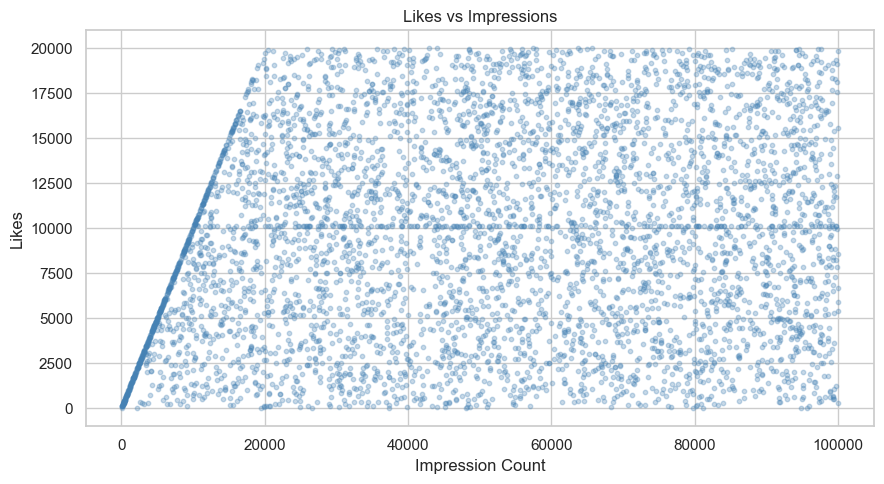

In [34]:
plt.figure(figsize=(9, 5))
plt.scatter(df['impression_count'], df['likes'], alpha=0.3, s=10, color='steelblue')
plt.title('Likes vs Impressions')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

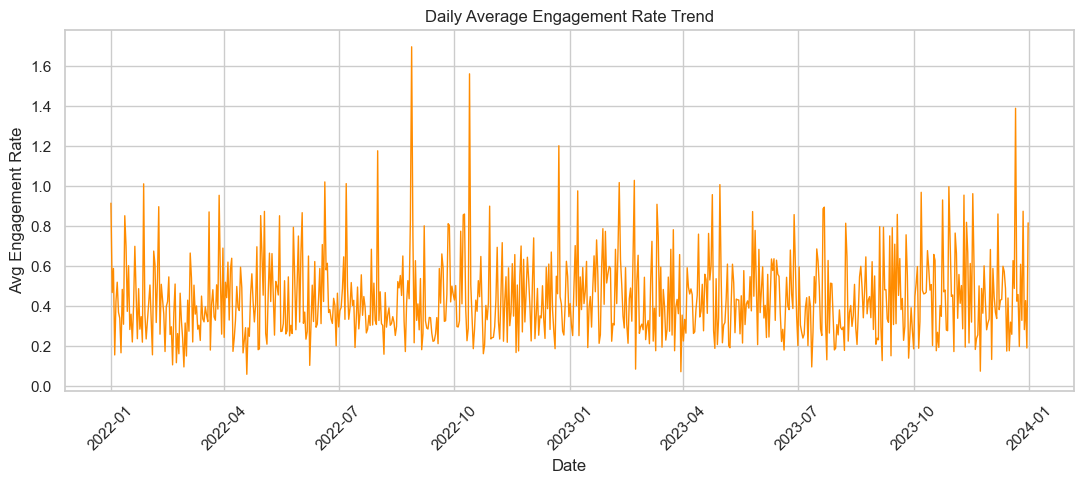

In [35]:
daily_trend = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()
plt.figure(figsize=(11, 5))
plt.plot(daily_trend.index, daily_trend.values, color='darkorange', linewidth=1)
plt.title('Daily Average Engagement Rate Trend')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

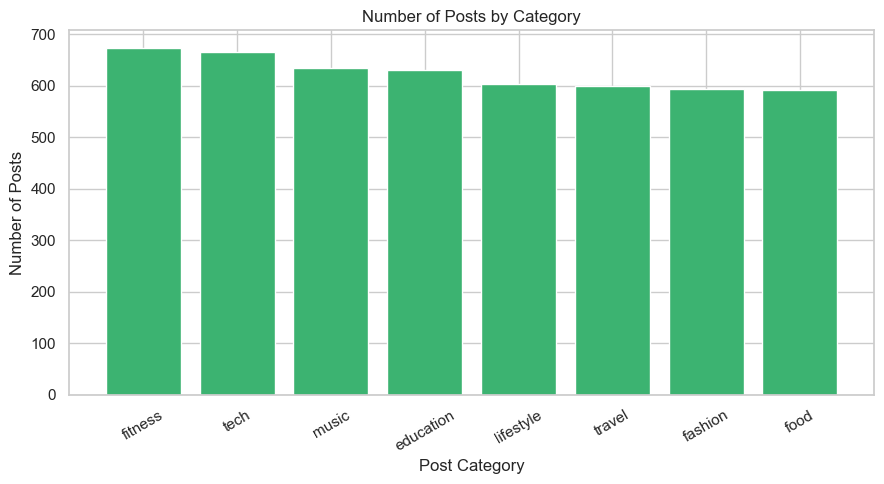

In [36]:
category_counts = df['post_category'].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(category_counts.index, category_counts.values, color='mediumseagreen')
plt.title('Number of Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

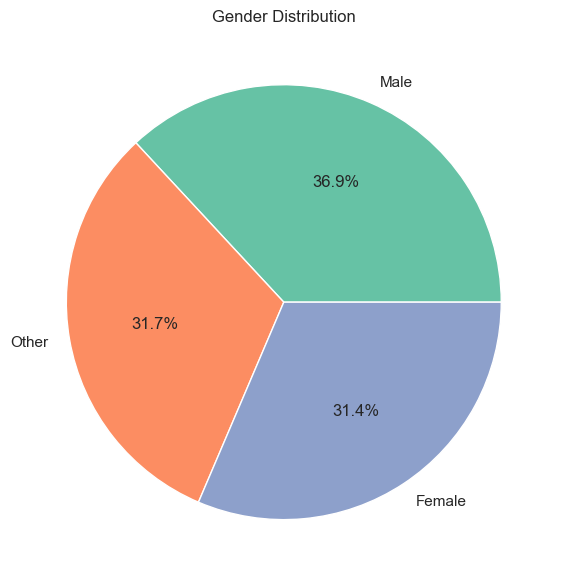

In [37]:
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

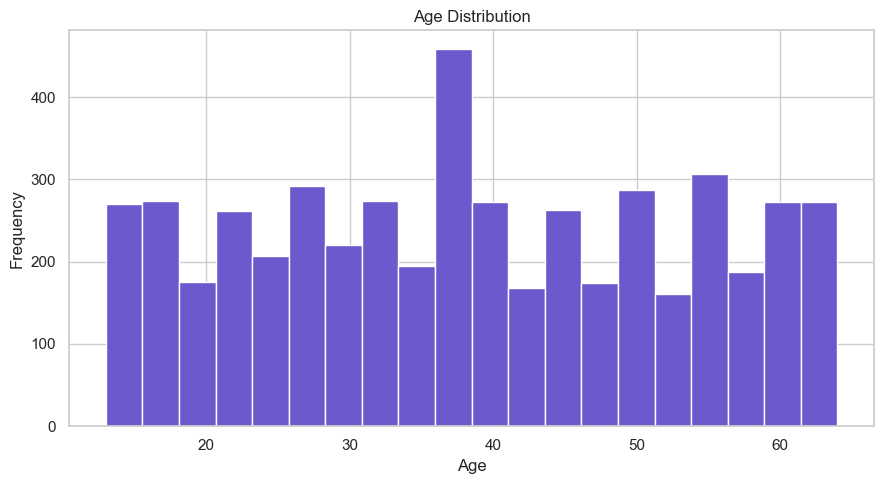

In [38]:
plt.figure(figsize=(9, 5))
plt.hist(df['age'], bins=20, color='slateblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

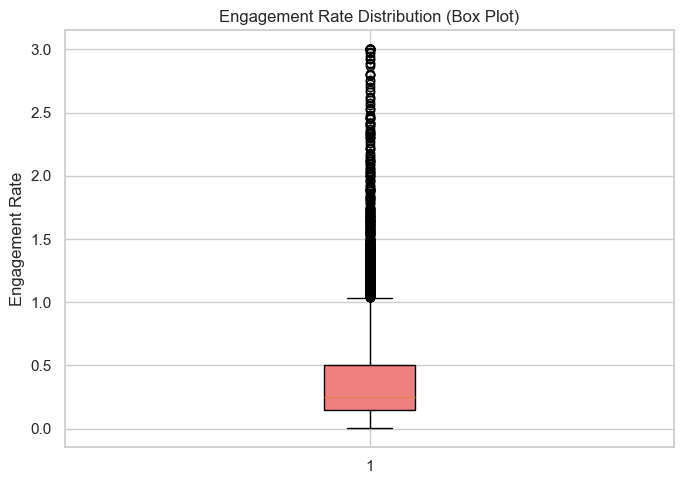

In [39]:
plt.figure(figsize=(7, 5))
plt.boxplot(df['engagement_rate'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral'))
plt.title('Engagement Rate Distribution (Box Plot)')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_13916\299390540.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




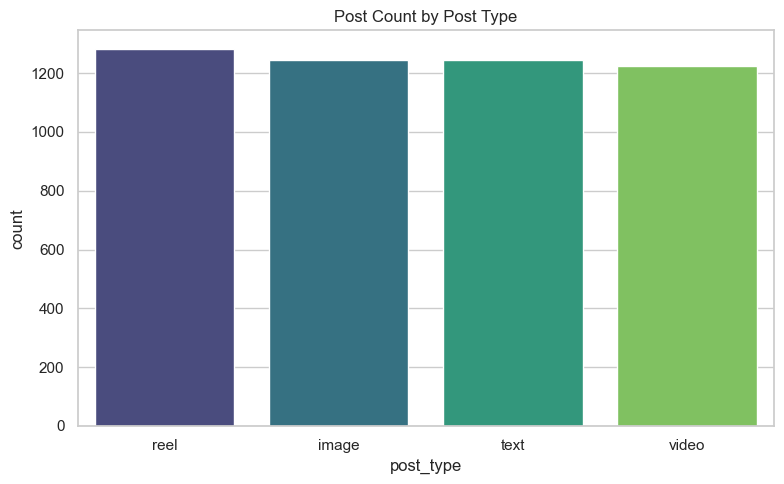

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='post_type', order=df['post_type'].value_counts().index, palette='viridis')
plt.title('Post Count by Post Type')
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_13916\2843254123.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




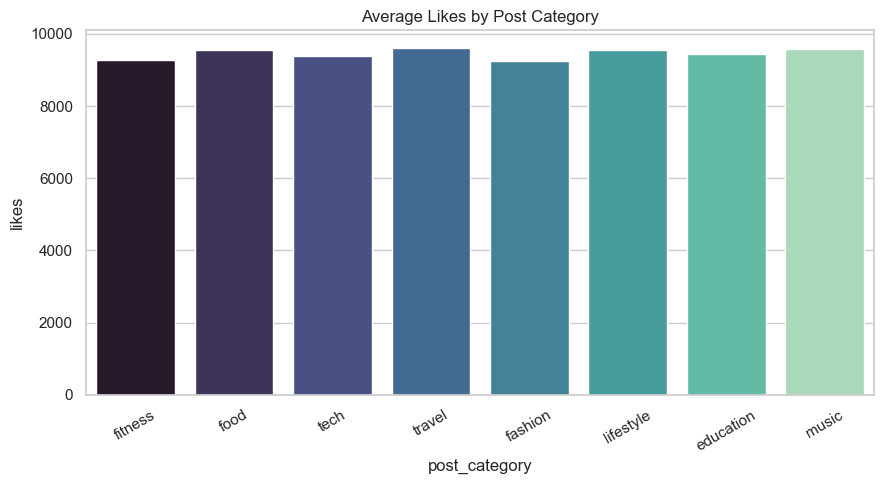

In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='post_category', y='likes', estimator='mean', errorbar=None, palette='mako')
plt.title('Average Likes by Post Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_13916\3691208308.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




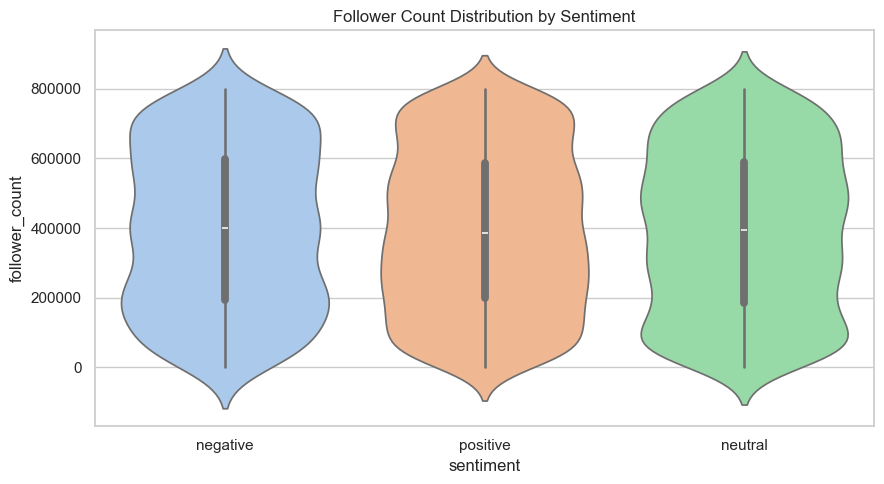

In [42]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='sentiment', y='follower_count', palette='pastel')
plt.title('Follower Count Distribution by Sentiment')
plt.tight_layout()
plt.show()

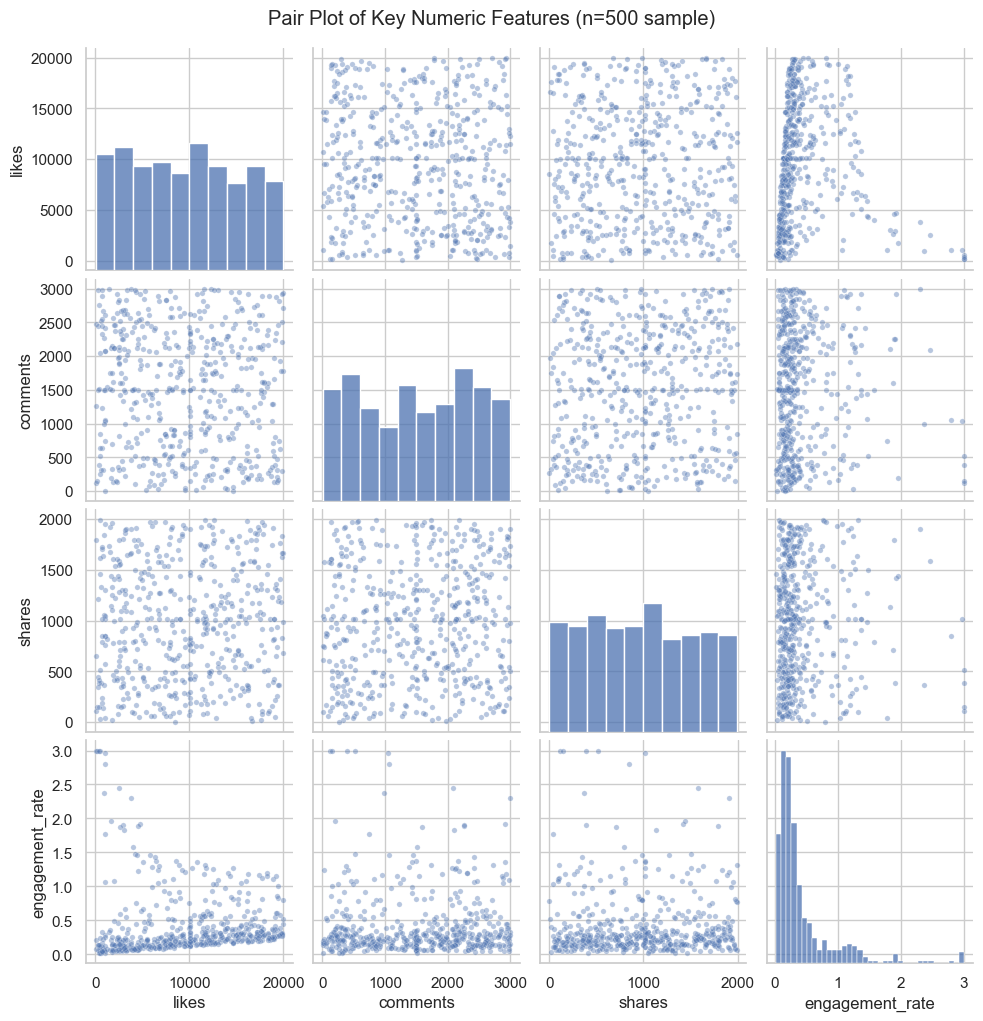

In [43]:
pair_cols = ['likes', 'comments', 'shares', 'engagement_rate']
sns.pairplot(df[pair_cols].sample(500, random_state=42), diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot of Key Numeric Features (n=500 sample)', y=1.02)
plt.show()

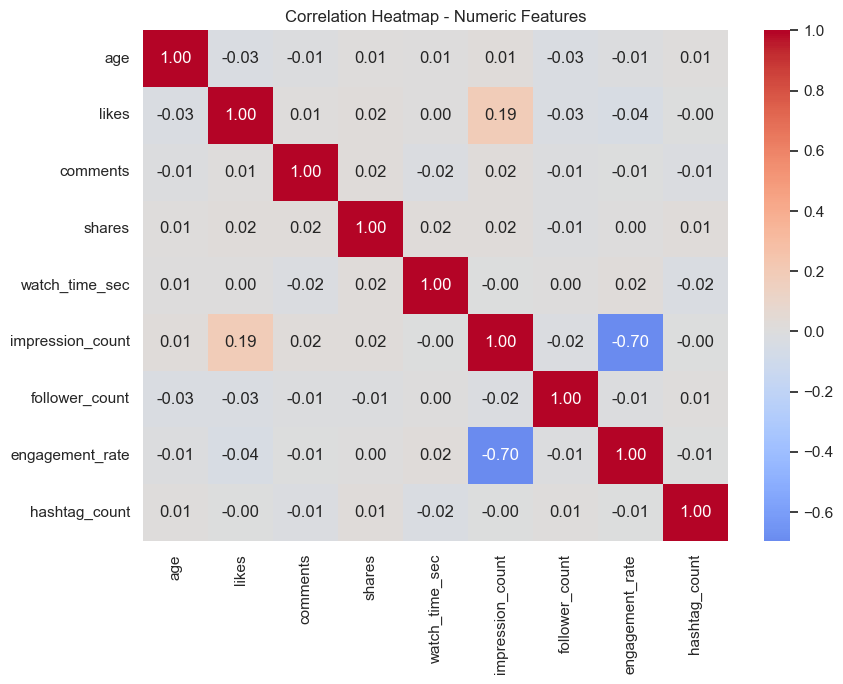

In [44]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_13916\3521565228.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




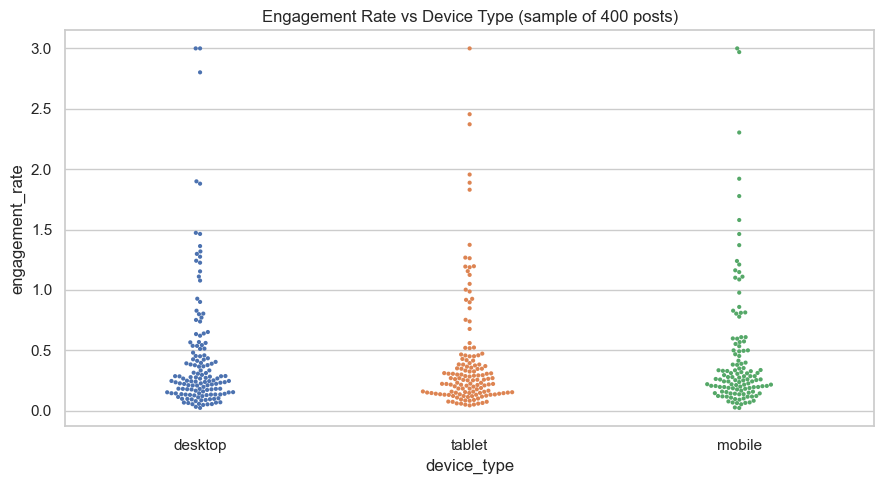

In [45]:
sample_df = df.sample(400, random_state=42)
plt.figure(figsize=(9, 5))
sns.swarmplot(data=sample_df, x='device_type', y='engagement_rate', size=3, palette='deep')
plt.title('Engagement Rate vs Device Type (sample of 400 posts)')
plt.tight_layout()
plt.show()

In [46]:
daily_trend_df = daily_trend.reset_index()
daily_trend_df.columns = ['date', 'avg_engagement_rate']
fig = px.line(daily_trend_df, x='date', y='avg_engagement_rate',
              title='Interactive: Daily Average Engagement Rate Trend')
fig.show()

In [47]:
country_engagement = df.groupby('country', observed=True)['engagement_rate'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(country_engagement, x='country', y='engagement_rate',
             title='Interactive: Average Engagement Rate by Country', color='engagement_rate',
             color_continuous_scale='Teal')
fig.show()

In [48]:
fig = px.scatter(df.sample(1000, random_state=42), x='impression_count', y='likes',
                  size='shares', color='sentiment', hover_data=['post_type', 'country'],
                  title='Interactive: Likes vs Impressions (bubble size = shares, n=1000 sample)',
                  opacity=0.6)
fig.show()

In [49]:
best_post_type = df.groupby('post_type', observed=True)['engagement_rate'].mean().idxmax()
best_category = df.groupby('post_category', observed=True)['likes'].mean().idxmax()
top_countries = df.groupby('country', observed=True)['engagement_rate'].mean().sort_values(ascending=False).head(3)

print(f"Post type with highest average engagement rate: {best_post_type}")
print(f"Best-performing content category (by avg likes): {best_category}")
print("Top 3 countries by average engagement rate:")
print(top_countries)

Post type with highest average engagement rate: video
Best-performing content category (by avg likes): travel
Top 3 countries by average engagement rate:
country
australia    0.490949
uae          0.469140
japan        0.460051
Name: engagement_rate, dtype: float64


In [50]:
age_engagement_corr = df['age'].corr(df['engagement_rate'])
verified_perf = df.groupby('is_verified')[['likes', 'comments', 'shares', 'engagement_rate']].mean().round(2)

print(f"Correlation between age and engagement rate: {age_engagement_corr:.3f}")
print("\nPerformance by verification status:")
print(verified_perf)

Correlation between age and engagement rate: -0.010

Performance by verification status:
               likes  comments   shares  engagement_rate
is_verified                                             
False        9502.73   1492.20   994.43             0.44
True         9022.51   1456.76  1006.18             0.42


In [51]:
df['day_of_week'] = df['posted_at'].dt.day_name()
impressions_by_day = df.groupby('day_of_week')['impression_count'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print("Average impressions by day of week (proxy for time-based pattern):")
print(impressions_by_day.round(0))

watch_time_by_device = df.groupby('device_type', observed=True)['watch_time_sec'].mean().sort_values(ascending=False)
print("\nAverage watch time by device type (seconds):")
print(watch_time_by_device.round(1))

Average impressions by day of week (proxy for time-based pattern):
day_of_week
Monday       50013.0
Tuesday      51354.0
Wednesday    49914.0
Thursday     48118.0
Friday       49414.0
Saturday     50945.0
Sunday       50375.0
Name: impression_count, dtype: float64

Average watch time by device type (seconds):
device_type
mobile     4087.6
tablet     3980.8
desktop    3975.8
Name: watch_time_sec, dtype: float64


In [52]:
sentiment_perf = df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_rate']].mean().round(2)
best_sentiment = sentiment_perf['engagement_rate'].idxmax()
print("Average performance by sentiment:")
print(sentiment_perf)
print(f"\nBest-performing sentiment (by avg engagement rate): {best_sentiment}")

negative_neutral = df[df['sentiment'].isin(['negative', 'neutral'])].groupby('sentiment')[['likes','comments','shares']].mean().round(2)
print("\nBehavior of negative/neutral sentiment posts (avg likes/comments/shares):")
print(negative_neutral)

Average performance by sentiment:
             likes  comments  shares  engagement_rate
sentiment                                            
negative   9376.76   1498.70  999.91             0.45
neutral    9287.16   1515.60  989.68             0.44
positive   9590.02   1468.71  997.48             0.43

Best-performing sentiment (by avg engagement rate): negative

Behavior of negative/neutral sentiment posts (avg likes/comments/shares):
             likes  comments  shares
sentiment                           
negative   9376.76    1498.7  999.91
neutral    9287.16    1515.6  989.68
